In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Đọc và tiền xử lý dữ liệu

In [160]:
df = pd.read_csv("candidate_scores.csv")
df

,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0000,0.8479,0.7524,0.764,0.8308,input,NaN,NaN,1,2026-05-24 00:03:11
1,2,1,email_field,v2,0.3633,1.0000,0.7832,0.6526,0.764,0.6974,input,NaN,NaN,0,2026-05-24 00:03:11
2,3,2,password_field,v2,0.9300,1.0000,0.8800,0.7396,0.764,0.8845,input,NaN,NaN,1,2026-05-24 00:03:12
3,4,2,password_field,v2,0.5467,0.9500,0.8086,0.7356,0.764,0.7541,input,NaN,NaN,0,2026-05-24 00:03:12
4,5,3,login_button,v2,0.9300,0.6359,1.0000,0.7298,0.764,0.8195,button,NaN,Xác nhận & Đăng nhập,1,2026-05-24 00:03:13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,746,198,filter_Tất cả_button,v11,0.8420,0.6200,0.8626,0.7143,0.764,0.7618,button,NaN,IPHONE,0,2026-05-24 01:25:33
746,747,198,filter_Tất cả_button,v11,0.8420,0.6785,0.8376,0.6169,0.764,0.7543,button,NaN,MACBOOK,0,2026-05-24 01:25:33
747,748,198,filter_Tất cả_button,v11,0.8420,0.6200,0.8501,0.6619,0.764,0.7504,button,NaN,IPAD,0,2026-05-24 01:25:33
748,749,198,filter_Tất cả_button,v11,0.8420,0.6200,0.8251,0.5468,0.764,0.7258,button,NaN,AIRPODS,0,2026-05-24 01:25:33


Nhận xét:
- Dữ liệu gồm **750 dòng** và **15 cột**
- Mỗi dòng là 1 candidate element trong 1 healing event
- Nhiều candidate thuộc cùng 1 `healing_event_id` (trung bình ~3.8 ứng viên/event)
- `is_correct = 1`: candidate đúng — `is_correct = 0`: candidate sai
- Tổng cộng **198 healing events** độc lập


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                750 non-null    int64  
 1   healing_event_id  750 non-null    int64  
 2   step_name         750 non-null    str    
 3   ui_version        750 non-null    str    
 4   attr_score        750 non-null    float64
 5   sem_score         750 non-null    float64
 6   struct_score      750 non-null    float64
 7   visual_score      750 non-null    float64
 8   ctx_score         750 non-null    float64
 9   total_score       750 non-null    float64
 10  cand_tag          750 non-null    str    
 11  cand_testid       370 non-null    str    
 12  cand_text         460 non-null    str    
 13  is_correct        750 non-null    int64  
 14  recorded_at       750 non-null    str    
dtypes: float64(6), int64(3), str(6)
memory usage: 88.0 KB


In [162]:
selected_cols = [
    "healing_event_id",
    "attr_score",
    "sem_score",
    "struct_score",
    "visual_score",
    "ctx_score",
    "is_correct"
]
train_df = df[selected_cols].copy()

print("\nMissing values:")
print(train_df.isnull().sum())

train_df = train_df.dropna()

print("\nShape after cleaning:", train_df.shape)


Missing values:
healing_event_id    0
attr_score          0
sem_score           0
struct_score        0
visual_score        0
ctx_score           0
is_correct          0
dtype: int64

Shape after cleaning: (750, 7)


Nhận xét:
- Chỉ giữ **5 sub-score** chính: `attr_score`, `sem_score`, `struct_score`, `visual_score`, `ctx_score`
- Không dùng `total_score` vì gây data leakage (là tổ hợp tuyến tính của các feature)
- `healing_event_id` giữ lại để thực hiện Group Split, không đưa vào training
- **Không có missing value** — shape sau cleaning vẫn là (750, 7)



Label distribution:
is_correct
0    552
1    198
Name: count, dtype: int64

Label ratio:
is_correct
0    0.736
1    0.264
Name: proportion, dtype: float64


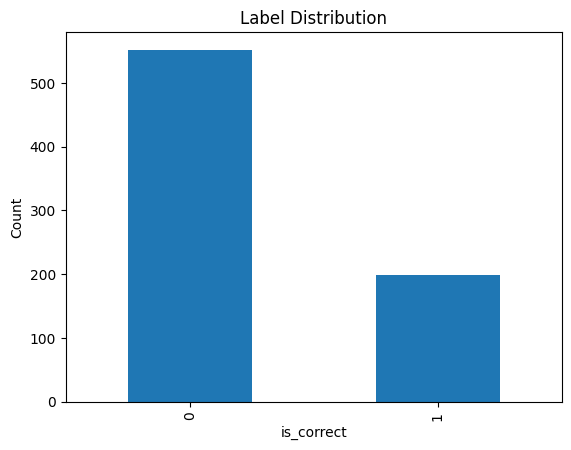

In [163]:
print("\nLabel distribution:")
print(train_df["is_correct"].value_counts())

print("\nLabel ratio:")
print(train_df["is_correct"].value_counts(normalize=True))

train_df["is_correct"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("is_correct")
plt.ylabel("Count")
plt.show()

Nhận xét:
- Label **mất cân bằng rõ rệt**: `is_correct=0` chiếm **73.6%** (552/750), `is_correct=1` chỉ **26.4%** (198/750)
- Tỷ lệ âm/dương ≈ 2.8:1 — mức imbalance vừa phải nhưng đủ để ảnh hưởng đến metric Accuracy
- → Dùng `class_weight='balanced'` để bù imbalance khi huấn luyện Logistic Regression


# Huấn luyện mô hình

In [164]:
X = train_df[[
    "attr_score",
    "sem_score",
    "struct_score",
    "visual_score",
    "ctx_score"
]]

y = train_df["is_correct"]
groups = train_df["healing_event_id"]

In [165]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

In [166]:
train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

In [167]:
train_idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  63,  64,  65,  66,  67,  68,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  98,  99,
       100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
       185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197,
       198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 20

In [168]:
test_idx

array([ 33,  60,  61,  62,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  92,  93,  94,  95,  96,  97, 120, 179, 180, 181,
       182, 183, 184, 226, 227, 228, 229, 230, 231, 232, 233, 243, 244,
       245, 246, 247, 248, 265, 278, 279, 280, 281, 282, 283, 284, 285,
       286, 287, 288, 289, 295, 296, 300, 301, 310, 311, 315, 316, 334,
       376, 377, 378, 379, 380, 381, 382, 383, 387, 388, 389, 393, 394,
       406, 407, 408, 409, 410, 411, 412, 413, 414, 447, 448, 449, 450,
       451, 452, 453, 454, 455, 456, 457, 458, 484, 485, 486, 487, 488,
       489, 502, 533, 540, 541, 542, 543, 544, 545, 558, 559, 560, 561,
       562, 563, 565, 566, 567, 568, 569, 570, 589, 590, 591, 592, 593,
       594, 608, 609, 610, 611, 612, 613, 627, 628, 629, 630, 631, 632,
       689, 690, 691, 692, 693, 694, 713, 714, 715, 716, 717, 718])

In [169]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

In [170]:
X_train

,attr_score,sem_score,struct_score,visual_score,ctx_score
0,0.7467,1.0000,0.8479,0.7524,0.764
1,0.3633,1.0000,0.7832,0.6526,0.764
2,0.9300,1.0000,0.8800,0.7396,0.764
3,0.5467,0.9500,0.8086,0.7356,0.764
4,0.9300,0.6359,1.0000,0.7298,0.764
...,...,...,...,...,...
745,0.8420,0.6200,0.8626,0.7143,0.764
746,0.8420,0.6785,0.8376,0.6169,0.764
747,0.8420,0.6200,0.8501,0.6619,0.764
748,0.8420,0.6200,0.8251,0.5468,0.764


In [171]:
X_test

,attr_score,sem_score,struct_score,visual_score,ctx_score
33,0.9900,1.0000,0.6200,0.7343,0.764
60,0.8282,1.0000,0.8584,0.6488,0.764
61,0.4167,0.9500,0.7900,0.7488,0.764
62,0.9020,1.0000,0.9606,0.6102,0.764
69,0.7482,1.0000,0.8169,0.6563,0.484
...,...,...,...,...,...
714,0.8420,0.6785,0.8193,0.6826,0.764
715,0.8420,0.6200,0.8193,0.7252,0.764
716,0.8420,0.6200,0.8193,0.6141,0.764
717,0.8420,0.6200,0.8193,0.5510,0.764


In [172]:
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [173]:
print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

print("Unique train events:", len(set(groups.iloc[train_idx])))
print("Unique test events:", len(set(groups.iloc[test_idx])))


Train size: (595, 5)
Test size: (155, 5)
Unique train events: 158
Unique test events: 40


Nhận xét:
- **KHÔNG** dùng `train_test_split` thông thường — có thể khiến cùng 1 healing event bị chia ra cả train lẫn test, gây **data leakage nghiêm trọng**
- `GroupShuffleSplit` đảm bảo mỗi `healing_event_id` chỉ xuất hiện ở **một phía** duy nhất
- Kết quả split: **Train = 595 samples / 158 events**, **Test = 155 samples / 40 events**
- Tỷ lệ test ≈ 20% số events (40/198) — đúng với `test_size=0.2`


In [174]:
model = LogisticRegression(
    class_weight="balanced",
    C=0.1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Nhận xét:
- **Logistic Regression** phù hợp cho bài toán này: hệ số `coef_` chính là trọng số tối ưu của từng sub-score
- `class_weight='balanced'`: tự động tăng trọng số class minority (`is_correct=1`) để bù mất cân bằng 73.6% vs 26.4%
- Dễ giải thích và có thể tích hợp trực tiếp trọng số vào công thức `total_score`

In [175]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [176]:
y_pred

array([1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0])

In [177]:
y_prob

array([0.60951042, 0.58632108, 0.49737237, 0.60512058, 0.55870209,
       0.46631739, 0.459077  , 0.45589871, 0.45302596, 0.45115907,
       0.52474518, 0.46243498, 0.42702343, 0.43109769, 0.43653139,
       0.43507873, 0.61999112, 0.42661174, 0.37789228, 0.36811874,
       0.35190186, 0.35190186, 0.46030119, 0.52603291, 0.42661174,
       0.37789228, 0.36811874, 0.36361633, 0.28577436, 0.49636034,
       0.36047501, 0.35471512, 0.35138051, 0.33154198, 0.28082894,
       0.38037924, 0.3015348 , 0.56021233, 0.52509627, 0.5075416 ,
       0.4719435 , 0.46969076, 0.45247438, 0.52127009, 0.62723649,
       0.5106397 , 0.49708334, 0.48956446, 0.48956446, 0.4862407 ,
       0.52997444, 0.39185592, 0.36047501, 0.33677532, 0.30328461,
       0.2827827 , 0.63896838, 0.51731651, 0.58264867, 0.46758899,
       0.52853547, 0.45327364, 0.60064401, 0.47735898, 0.39920495,
       0.57920468, 0.53415671, 0.50850838, 0.57078081, 0.55193012,
       0.52063494, 0.5722598 , 0.39565355, 0.52539312, 0.47987

In [178]:
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [179]:
print("\n===== MODEL EVALUATION =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



===== MODEL EVALUATION =====
Accuracy  : 0.8387
Precision : 0.6531
Recall    : 0.8000
F1-score  : 0.7191
ROC-AUC   : 0.9178

Confusion Matrix:
[[98 17]
 [ 8 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       115
           1       0.65      0.80      0.72        40

    accuracy                           0.84       155
   macro avg       0.79      0.83      0.80       155
weighted avg       0.85      0.84      0.84       155



Do dữ liệu healing có mất cân bằng giữa candidate đúng và sai, **Accuracy không phải chỉ số đánh giá chính** — model có thể đạt Accuracy cao ngay cả khi dự đoán kém trên class positive.

Kết quả thực nghiệm trên **40 healing events test** (155 samples):

| Metric | Giá trị | Đánh giá |
|--------|---------|----------|
| Accuracy | 0.8387 | Khá tốt nhưng không phải chỉ số chính |
| Precision | 0.6531 | 17 false positive — model dự đoán thừa positive |
| Recall | 0.8000 | Bỏ sót 8/40 ứng viên đúng ở cấp candidate |
| F1-score | 0.7191 | Cân bằng Precision/Recall ở mức tốt |
| **ROC-AUC** | **0.9178** | model phân tách tốt 2 class |

Confusion Matrix: `[[98 FP=17], [FN=8, TP=32]]` — trong 40 positive test samples, model nhận đúng 32/40.

→ Trong bài toán self-healing, ưu tiên đánh giá bằng **ROC-AUC**, **Recall** và đặc biệt **Top-1 Success Rate** ở mức healing event.


- **Top-1 Success Rate = 100% (40/40)** là chỉ số quan trọng nhất — dù Recall ở cấp candidate là 80%, khi xét toàn bộ event, ứng viên đúng luôn được model xếp hạng cao nhất. Không có failed event nào.
- **Recall = 80.0%** ở cấp candidate — model bỏ sót 8 ứng viên đúng, nhưng trong cùng event đó vẫn có ứng viên đúng được score cao nhất → không ảnh hưởng Top-1.
- **Precision = 65.3%** — 17 false positive (ứng viên sai bị dự đoán là đúng). Điều này không ảnh hưởng Top-1 vì ứng viên đúng vẫn có `pred_prob` cao hơn.
- **ROC-AUC = 0.9178** — model phân tách cực tốt giữa candidate đúng và sai, phù hợp với mục tiêu ranking.


In [180]:
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

In [181]:
test_df["pred_prob"] = y_prob

top1_result = (
    test_df
    .sort_values(
        ["healing_event_id", "pred_prob"],
        ascending=[True, False]
    )
    .groupby("healing_event_id")
    .first()
    .reset_index()
)


In [182]:
event_total = len(top1_result)
event_success = top1_result["is_correct"].sum()
event_accuracy = event_success / event_total

print(f"Total healing events : {event_total}")
print(f"Successful healing   : {event_success}")
print(f"Top-1 Success Rate   : {event_accuracy:.4f}")

Total healing events : 40
Successful healing   : 40
Top-1 Success Rate   : 1.0000


In [183]:
failed_events = top1_result[
    top1_result["is_correct"] == 0
]

print("\nFailed Events:")
if len(failed_events) == 0:
    print("No failed events ✓")
else:
    print(
        failed_events[
            [
                "healing_event_id",
                "step_name",
                "ui_version",
                "pred_prob",
                "total_score",
                "cand_tag",
                "cand_testid",
                "cand_text"
            ]
        ]
    )



Failed Events:
No failed events ✓


In [184]:
print("\n" + "=" * 60)
print("LEARNED WEIGHTS")
print("=" * 60)
feature_cols = [
    "attr_score",
    "sem_score",
    "struct_score",
    "visual_score",
    "ctx_score"
]
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0]
})

coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df["Normalized Weight"] = (
    coef_df["Abs"] /
    coef_df["Abs"].sum()
)

coef_df = coef_df.sort_values(
    "Normalized Weight",
    ascending=False
)

print(
    coef_df[
        [
            "Feature",
            "Coefficient",
            "Normalized Weight"
        ]
    ]
)


LEARNED WEIGHTS
        Feature  Coefficient  Normalized Weight
1     sem_score     1.701147           0.386696
3  visual_score     1.156772           0.262951
0    attr_score     0.849951           0.193206
2  struct_score     0.587034           0.133441
4     ctx_score     0.104282           0.023705


Kết quả Logistic Regression học được trọng số tối ưu từ dữ liệu thực nghiệm:

| Feature | Coefficient | Normalized Weight |
|---------|-------------|-------------------|
| `sem_score` | 1.7011 | **38.7%** |
| `visual_score` | 1.1568 | **26.3%** |
| `attr_score` | 0.8500 | **19.3%** |
| `struct_score` | 0.5870 | **13.3%** |
| `ctx_score` | 0.1043 | **2.4%** |

- **`sem_score` dẫn đầu (38.7%)** — ngữ nghĩa là yếu tố phân biệt mạnh nhất giữa candidate đúng và sai.
- **`visual_score` cao thứ 2 (26.3%)** — phần tử đúng thường giữ vị trí trực quan ổn định dù thuộc tính thay đổi.
- **`ctx_score` gần như không đóng góp (2.4%)** — cần xem xét giảm trọng số hoặc loại khỏi `total_score`.
- Tất cả coefficient đều **dương** → tất cả feature đều có tương quan thuận với `is_correct`, không có feature nghịch chiều.
- Hiện tượng **multicollinearity** giữa `attr`, `sem`, `struct` có thể khiến model dồn trọng số vào `sem_score` như feature đại diện.


In [185]:
final_weights = dict(
    zip(
        coef_df["Feature"],
        coef_df["Normalized Weight"]
    )
)

print("\n" + "=" * 60)
print("FINAL ML-OPTIMIZED WEIGHTS")
print("=" * 60)

print(final_weights)



FINAL ML-OPTIMIZED WEIGHTS
{'sem_score': 0.38669577893574525, 'visual_score': 0.26295142415737927, 'attr_score': 0.19320643697943152, 'struct_score': 0.13344142862459682, 'ctx_score': 0.02370493130284699}


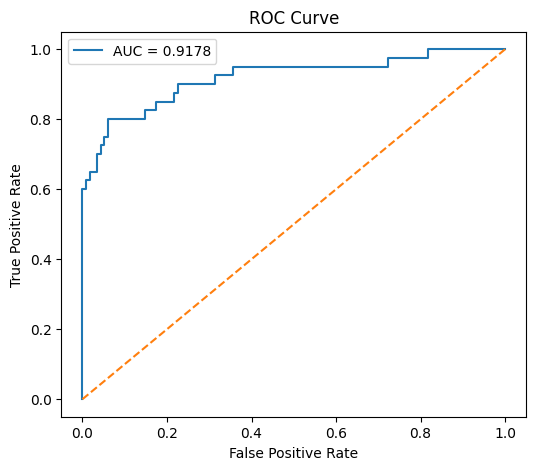

In [186]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()